In [121]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sehaj1104/student-mental-health-and-burnout-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\MICROSOFT\.cache\kagglehub\datasets\sehaj1104\student-mental-health-and-burnout-dataset\versions\1


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [123]:
df = pd.read_csv(path + "/student_mental_health_burnout.csv")
df.head()

,student_id,age,gender,course,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,academic_pressure_score,financial_stress_score,social_support_score,physical_activity_hours,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level
0,100001,23,Male,BTech,1st,4.3,6.8,6.1,High,10,3,4,2,6,1.8,Average,66.5,9.63,Good,High
1,100002,20,Male,BTech,3rd,1.4,4.7,3.0,High,2,10,8,5,9,1.9,Poor,55.8,6.04,Poor,Low
2,100003,24,Female,BCA,4th,3.7,4.8,1.5,Low,2,7,8,6,3,0.8,Good,85.0,8.31,Good,High
3,100004,21,Male,BSc,4th,1.6,6.7,7.0,High,3,3,4,9,9,0.7,Poor,89.1,5.95,Good,High
4,100005,23,Other,BSc,4th,2.0,6.7,5.4,High,7,7,6,4,4,1.7,Good,58.7,8.51,Good,Low


In [124]:
print(df["gender"].unique())

['Male' 'Female' 'Other']


In [125]:
print(df.shape)

(150000, 20)


In [126]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  object 
 3   course                   150000 non-null  object 
 4   year                     150000 non-null  object 
 5   daily_study_hours        150000 non-null  float64
 6   daily_sleep_hours        150000 non-null  float64
 7   screen_time_hours        150000 non-null  float64
 8   stress_level             150000 non-null  object 
 9   anxiety_score            150000 non-null  int64  
 10  depression_score         150000 non-null  int64  
 11  academic_pressure_score  150000 non-null  int64  
 12  financial_stress_score   150000 non-null  int64  
 13  social_support_score     150000 non-null  int64  
 14  phys

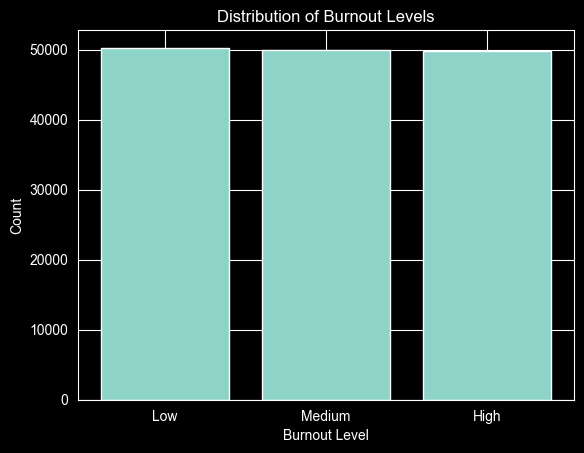

In [127]:
plt.bar(df["burnout_level"].value_counts().index, df["burnout_level"].value_counts().values)
plt.xlabel("Burnout Level")
plt.ylabel("Count")
plt.title("Distribution of Burnout Levels")
plt.show()

the dataset is balanced

## Data preprocessing

In [128]:
df_pre = df.copy()
print(df.duplicated().sum())

0


In [129]:
map_year = {"1st": 1, "2nd": 2, "3rd": 3, "4th": 4}
map_gender = {"Male": 1, "Female": 0, "Other": 2}
map_sleep_quality = {"Poor": 0, "Average": 1, "Good": 2}
map_stress_level = {"Low": 0, "Medium": 1, "High": 2}
map_internet_quality = {"Poor": 0, "Average": 1, "Good": 2}
map_burnout_level = {"Low": 0, "Medium": 1, "High": 2}


df_pre["year"] = df_pre["year"].map(map_year)
df_pre["gender"] = df_pre["gender"].map(map_gender)
df_pre = pd.get_dummies(df_pre, columns=["course"], drop_first=True)
df_pre["sleep_quality"] = df_pre["sleep_quality"].map(map_sleep_quality)
df_pre["internet_quality"] = df_pre["internet_quality"].map(map_internet_quality)
df_pre["stress_level"] = df_pre["stress_level"].map(map_stress_level)
df_pre["burnout_level"] = df_pre["burnout_level"].map(map_burnout_level)


In [130]:
print(df_pre.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   student_id               150000 non-null  int64  
 1   age                      150000 non-null  int64  
 2   gender                   150000 non-null  int64  
 3   year                     150000 non-null  int64  
 4   daily_study_hours        150000 non-null  float64
 5   daily_sleep_hours        150000 non-null  float64
 6   screen_time_hours        150000 non-null  float64
 7   stress_level             150000 non-null  int64  
 8   anxiety_score            150000 non-null  int64  
 9   depression_score         150000 non-null  int64  
 10  academic_pressure_score  150000 non-null  int64  
 11  financial_stress_score   150000 non-null  int64  
 12  social_support_score     150000 non-null  int64  
 13  physical_activity_hours  150000 non-null  float64
 14  slee

In [131]:
df_pre.head()

,student_id,age,gender,year,daily_study_hours,daily_sleep_hours,screen_time_hours,stress_level,anxiety_score,depression_score,...,sleep_quality,attendance_percentage,cgpa,internet_quality,burnout_level,course_BCA,course_BSc,course_BTech,course_MBA,course_MCA
0,100001,23,1,1,4.3,6.8,6.1,2,10,3,...,1,66.5,9.63,2,2,False,False,True,False,False
1,100002,20,1,3,1.4,4.7,3.0,2,2,10,...,0,55.8,6.04,0,0,False,False,True,False,False
2,100003,24,0,4,3.7,4.8,1.5,0,2,7,...,2,85.0,8.31,2,2,True,False,False,False,False
3,100004,21,1,4,1.6,6.7,7.0,2,3,3,...,0,89.1,5.95,2,2,False,True,False,False,False
4,100005,23,2,4,2.0,6.7,5.4,2,7,7,...,2,58.7,8.51,2,0,False,True,False,False,False


`student_id` is not useful for modeling, so we can drop it

In [132]:
df_pre.drop("student_id", axis=1, inplace=True)

## Feature engineering

In [133]:
df_pre["mental_health_score"] = (df_pre['stress_level'] + df_pre['anxiety_score'] + df_pre['depression_score']) / 3

df_pre['lifestyle_balance'] = (
    df_pre['daily_sleep_hours'] + df_pre['physical_activity_hours']
) - df_pre['screen_time_hours']

df_pre['pressure_ratio'] = df_pre['academic_pressure_score'] / (df_pre['daily_study_hours'] + 1)

df_pre['sleep_effectiveness'] = df_pre['daily_sleep_hours'] * df_pre['sleep_quality']

df_pre['stress_support_ratio'] = df_pre['stress_level'] / (df_pre['social_support_score'] + 1)

df_pre['total_load'] = (
    df_pre['academic_pressure_score'] +
    df_pre['financial_stress_score'] +
    df_pre['stress_level']
)

df_pre['health_score'] = (
    df_pre['daily_sleep_hours'] +
    df_pre['physical_activity_hours'] +
    df_pre['sleep_quality']
) / 3

In [134]:
X = df_pre.drop("burnout_level", axis=1)
y = df_pre["burnout_level"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale some features

In [135]:
scaler = StandardScaler()

cols_to_scale = ['age', 'attendance_percentage']

# Fit on training data
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transform test data
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Model Training and Evaluation

In [136]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    print(f"Model: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-" * 50)

Model: Logistic Regression
Accuracy: 0.3314666666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.47      0.39     10024
           1       0.33      0.31      0.32      9955
           2       0.33      0.22      0.26     10021

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.32     30000
weighted avg       0.33      0.33      0.32     30000

Confusion Matrix:
 [[4687 3049 2288]
 [4639 3039 2277]
 [4732 3071 2218]]
--------------------------------------------------
Model: Random Forest
Accuracy: 0.33176666666666665
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.36      0.35     10024
           1       0.33      0.33      0.33      9955
           2       0.33      0.30      0.32     10021

    accuracy                           0.33     30000
   macro avg       0.33      0.33      0.33     30000
weighted avg 

## Check correlation with target

In [137]:
corr = df_pre.corr(numeric_only=True)
print(corr['burnout_level'])

age                       -0.001565
gender                    -0.004257
year                      -0.001149
daily_study_hours          0.000270
daily_sleep_hours         -0.003356
screen_time_hours         -0.003048
stress_level               0.002563
anxiety_score             -0.002011
depression_score           0.000985
academic_pressure_score    0.003649
financial_stress_score     0.001067
social_support_score      -0.000818
physical_activity_hours   -0.000436
sleep_quality             -0.000591
attendance_percentage     -0.002262
cgpa                      -0.000613
internet_quality           0.001547
burnout_level              1.000000
course_BCA                 0.001470
course_BSc                -0.004590
course_BTech               0.002781
course_MBA                 0.000675
course_MCA                -0.001359
mental_health_score       -0.000207
lifestyle_balance          0.001298
pressure_ratio             0.001972
sleep_effectiveness       -0.002390
stress_support_ratio       0

### all correlations ≈ 0 → dataset is weak

The results (~33%) are basically **random guessing** for 3 classes.
That means:

> The model is NOT finding any real pattern in your data.

---

# Why this is happening

## 1. This dataset is synthetic (this is the BIGGEST reason) and it is uniformly distributed across classes.

* Features are **randomly generated**
* Target (`burnout_level`) is **not strongly linked** to features

Result:
Models can’t learn anything -> performance = random (33%)

---

```text
Predictions are almost evenly distributed across classes
```
That means:

* Model is guessing
* No strong signal exists

---

#  Should we use Deep Learning?

**NO**

Why:

* Deep learning needs **strong patterns**
* You currently have **weak/no signal**

It will still give ~33%

---
